# RBF 최적화 시스템 - Phase 1~2: Olist 데이터 전처리 및 판매자 유형 분류

## 프로젝트 개요
- **목적**: 판매자별 매출 시계열 생성 → 유형 분류 → 시계열 예측 → CVaR 최적화 / RL 동적 조정
- **데이터**: Olist Brazilian E-Commerce Dataset
- **Phase 1**: Olist 데이터 전처리 (Step 1~3)
- **Phase 2**: 판매자 유형 분류 (Step 4~5)

In [21]:
# 공통 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (macOS)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 데이터 경로 설정
DATA_PATH = Path('./Data/Olist_Data')
print(f'데이터 경로: {DATA_PATH.resolve()}')
print('라이브러리 임포트 완료!')

데이터 경로: /Users/eoseungyun/Desktop/project/SW_Capstone/Project/Data/Olist_Data
라이브러리 임포트 완료!


---
# Phase 1: Olist 데이터 전처리

## Step 1. 데이터 구조 파악
각 CSV 파일의 컬럼, 결측치, 데이터 타입 확인

In [22]:
# ─────────────────────────────────────────────
# Step 1-1. 전체 CSV 파일 목록 확인
# ─────────────────────────────────────────────
csv_files = list(DATA_PATH.glob('*.csv'))
print(f'총 CSV 파일 수: {len(csv_files)}개')
for f in sorted(csv_files):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f'  {f.name:55s}  {size_mb:6.2f} MB')

총 CSV 파일 수: 9개
  olist_customers_dataset.csv                                8.62 MB
  olist_geolocation_dataset.csv                             58.44 MB
  olist_order_items_dataset.csv                             14.72 MB
  olist_order_payments_dataset.csv                           5.51 MB
  olist_order_reviews_dataset.csv                           13.78 MB
  olist_orders_dataset.csv                                  16.84 MB
  olist_products_dataset.csv                                 2.27 MB
  olist_sellers_dataset.csv                                  0.17 MB
  product_category_name_translation.csv                      0.00 MB


In [23]:
# ─────────────────────────────────────────────
# Step 1-2. 각 테이블 로드 및 기본 정보 확인
# ─────────────────────────────────────────────
def inspect_df(name, df):
    """데이터프레임 기본 정보 출력 함수"""
    print('='*60)
    print(f'  📄 {name}')
    print('='*60)
    print(f'  - Shape : {df.shape[0]:,} rows × {df.shape[1]} cols')
    print(f'  - Columns: {list(df.columns)}')
    print()
    
    # 결측치 + 데이터 타입
    info = pd.DataFrame({
        'dtype': df.dtypes,
        'null_count': df.isnull().sum(),
        'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
        'nunique': df.nunique()
    })
    print(info.to_string())
    print()
    print('  [ 샘플 (head 3) ]')
    display(df.head(3))

# 테이블 로드
orders       = pd.read_csv(DATA_PATH / 'olist_orders_dataset.csv')
order_items  = pd.read_csv(DATA_PATH / 'olist_order_items_dataset.csv')
sellers      = pd.read_csv(DATA_PATH / 'olist_sellers_dataset.csv')
products     = pd.read_csv(DATA_PATH / 'olist_products_dataset.csv')
customers    = pd.read_csv(DATA_PATH / 'olist_customers_dataset.csv')
payments     = pd.read_csv(DATA_PATH / 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(DATA_PATH / 'olist_order_reviews_dataset.csv')
geolocation  = pd.read_csv(DATA_PATH / 'olist_geolocation_dataset.csv')
category_map = pd.read_csv(DATA_PATH / 'product_category_name_translation.csv')

tables = {
    'orders':       orders,
    'order_items':  order_items,
    'sellers':      sellers,
    'products':     products,
    'customers':    customers,
    'payments':     payments,
    'reviews':      reviews,
    'geolocation':  geolocation,
    'category_map': category_map,
}

for name, df in tables.items():
    inspect_df(name, df)

  📄 orders
  - Shape : 99,441 rows × 8 cols
  - Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

                                dtype  null_count  null_pct  nunique
order_id                       object           0      0.00    99441
customer_id                    object           0      0.00    99441
order_status                   object           0      0.00        8
order_purchase_timestamp       object           0      0.00    98875
order_approved_at              object         160      0.16    90733
order_delivered_carrier_date   object        1783      1.79    81018
order_delivered_customer_date  object        2965      2.98    95664
order_estimated_delivery_date  object           0      0.00      459

  [ 샘플 (head 3) ]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


  📄 order_items
  - Shape : 112,650 rows × 7 cols
  - Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

                       dtype  null_count  null_pct  nunique
order_id              object           0       0.0    98666
order_item_id          int64           0       0.0       21
product_id            object           0       0.0    32951
seller_id             object           0       0.0     3095
shipping_limit_date   object           0       0.0    93318
price                float64           0       0.0     5968
freight_value        float64           0       0.0     6999

  [ 샘플 (head 3) ]


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


  📄 sellers
  - Shape : 3,095 rows × 4 cols
  - Columns: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

                         dtype  null_count  null_pct  nunique
seller_id               object           0       0.0     3095
seller_zip_code_prefix   int64           0       0.0     2246
seller_city             object           0       0.0      611
seller_state            object           0       0.0       23

  [ 샘플 (head 3) ]


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


  📄 geolocation
  - Shape : 1,000,163 rows × 5 cols
  - Columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

                               dtype  null_count  null_pct  nunique
geolocation_zip_code_prefix    int64           0       0.0    19015
geolocation_lat              float64           0       0.0   717360
geolocation_lng              float64           0       0.0   717613
geolocation_city              object           0       0.0     8011
geolocation_state             object           0       0.0       27

  [ 샘플 (head 3) ]


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


  📄 category_map
  - Shape : 71 rows × 2 cols
  - Columns: ['product_category_name', 'product_category_name_english']

                                dtype  null_count  null_pct  nunique
product_category_name          object           0       0.0       71
product_category_name_english  object           0       0.0       71

  [ 샘플 (head 3) ]


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [24]:
# ─────────────────────────────────────────────
# Step 1-3. 핵심 테이블 상세 확인 (Phase 용)
# ─────────────────────────────────────────────

# orders 날짜 컬럼 파싱
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print('=== orders 날짜 범위 ===')
print(f"주문 기간: {orders['order_purchase_timestamp'].min().date()} ~ "
      f"{orders['order_purchase_timestamp'].max().date()}")
print(f"주문 상태 분포:\n{orders['order_status'].value_counts()}")

print('\n=== order_items price 통계 ===')
print(order_items[['price', 'freight_value']].describe())

print('\n=== sellers 지역 분포 (상위 10개) ===')
print(sellers['seller_state'].value_counts().head(10))

print('\n✅ Step 1 완료 - 데이터 구조 파악 완료')

=== orders 날짜 범위 ===
주문 기간: 2016-09-04 ~ 2018-10-17
주문 상태 분포:
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

=== order_items price 통계 ===
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000

=== sellers 지역 분포 (상위 10개) ===
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: seller_state, dtype: int64

✅ Step 1 완료 - 데이터 구조 파악 완료


---
## Step 2. 테이블 병합
`orders` + `order_items` + `sellers` + `products` → **판매자별 일별 매출 테이블** 생성

In [25]:
# ─────────────────────────────────────────────
# Step 2-1. 배송 완료 주문만 필터링
# ─────────────────────────────────────────────
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'전체 주문: {len(orders):,}건  →  배송완료: {len(orders_delivered):,}건')
print(f'필터링 비율: {len(orders_delivered)/len(orders)*100:.1f}%')

# 날짜 컬럼 추출 (일별)
orders_delivered['order_purchase_timestamp'] = pd.to_datetime(orders_delivered['order_purchase_timestamp'])
orders_delivered['order_date'] = orders_delivered['order_purchase_timestamp'].dt.date
orders_delivered['order_year'] = orders_delivered['order_purchase_timestamp'].dt.year
orders_delivered['order_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

전체 주문: 99,441건  →  배송완료: 96,478건
필터링 비율: 97.0%


In [26]:
# ─────────────────────────────────────────────
# Step 2-2. orders + order_items 병합
# ─────────────────────────────────────────────
df_merged = orders_delivered[[
    'order_id', 'order_date', 'order_month', 'order_year',
    'order_purchase_timestamp'
]].merge(order_items[[
    'order_id', 'seller_id', 'product_id', 'price', 'freight_value'
]], on='order_id', how='inner')

print(f'orders_delivered + order_items 병합 결과: {df_merged.shape}')

# ─────────────────────────────────────────────
# Step 2-3. sellers 병합
# ─────────────────────────────────────────────
df_merged = df_merged.merge(
    sellers[['seller_id', 'seller_city', 'seller_state']],
    on='seller_id', how='left'
)

# ─────────────────────────────────────────────
# Step 2-4. products + category 번역 병합
# ─────────────────────────────────────────────
products_en = products.merge(category_map, on='product_category_name', how='left')

df_merged = df_merged.merge(
    products_en[['product_id', 'product_category_name', 'product_category_name_english']],
    on='product_id', how='left'
)

print(f'최종 병합 결과: {df_merged.shape}')
print(f'컬럼 목록: {list(df_merged.columns)}')
print(f'\n결측치 현황:')
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])
display(df_merged.head(5))

orders_delivered + order_items 병합 결과: (110197, 9)
최종 병합 결과: (110197, 13)
컬럼 목록: ['order_id', 'order_date', 'order_month', 'order_year', 'order_purchase_timestamp', 'seller_id', 'product_id', 'price', 'freight_value', 'seller_city', 'seller_state', 'product_category_name', 'product_category_name_english']

결측치 현황:
product_category_name            1537
product_category_name_english    1559
dtype: int64


,order_id,order_date,order_month,order_year,order_purchase_timestamp,seller_id,product_id,price,freight_value,seller_city,seller_state,product_category_name,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02,2017-10,2017,2017-10-02 10:56:33,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,29.99,8.72,maua,SP,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24,2018-07,2018,2018-07-24 20:41:37,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,belo horizonte,SP,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08,2018-08,2018,2018-08-08 08:38:49,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,159.90,19.22,guariba,SP,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18,2017-11,2017,2017-11-18 19:28:06,66922902710d126a0e7d26b0e3805106,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,belo horizonte,MG,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13,2018-02,2018,2018-02-13 21:18:39,2c9e548be18521d1c43cde1c582c6de8,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,mogi das cruzes,SP,papelaria,stationery


In [27]:
# ─────────────────────────────────────────────
# Step 2-5. 매출(revenue) 컬럼 생성
# RBF에서 매출 = 판매가격 (freight는 제외하거나 포함 가능)
# 여기서는 price만을 매출로 정의 (freight_value는 별도 분석용)
# ─────────────────────────────────────────────
df_merged['revenue'] = df_merged['price']  # freight 제외
df_merged['gross_revenue'] = df_merged['price'] + df_merged['freight_value']  # freight 포함

print('=== revenue 통계 ===')
print(df_merged[['revenue', 'gross_revenue']].describe())
print(f'\n고유 판매자 수: {df_merged["seller_id"].nunique():,}명')
print(f'고유 주문 수  : {df_merged["order_id"].nunique():,}건')
print('\n✅ Step 2 완료 - 테이블 병합 완료')

=== revenue 통계 ===
             revenue  gross_revenue
count  110197.000000  110197.000000
mean      119.980563     139.929161
std       182.299446     189.319151
min         0.850000       6.080000
25%        39.900000      55.180000
50%        74.900000      92.130000
75%       134.170000     157.510000
max      6735.000000    6929.310000

고유 판매자 수: 2,970명
고유 주문 수  : 96,478건

✅ Step 2 완료 - 테이블 병합 완료


---
## Step 3. 판매자별 매출 시계열 생성
- seller_id × 날짜별 매출 합산
- 결측 날짜 처리 (매출 0인 날 보완)
- 월별 집계로 변환

In [28]:
# ─────────────────────────────────────────────
# Step 3-1. 판매자별 일별 매출 집계
# ─────────────────────────────────────────────
daily_seller = (
    df_merged
    .groupby(['seller_id', 'order_date'])
    .agg(
        daily_revenue=('revenue', 'sum'),
        daily_orders=('order_id', 'nunique'),
        daily_items=('order_id', 'count')
    )
    .reset_index()
)
daily_seller['order_date'] = pd.to_datetime(daily_seller['order_date'])

print(f'판매자별 일별 집계 shape: {daily_seller.shape}')
print(f'고유 판매자 수: {daily_seller["seller_id"].nunique():,}명')
display(daily_seller.head(10))

판매자별 일별 집계 shape: (68019, 5)
고유 판매자 수: 2,970명


,seller_id,order_date,daily_revenue,daily_orders,daily_items
0,0015a82c2db000af6aaaf3ae2ecb0532,2017-09-26,895.0,1,1
1,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-12,895.0,1,1
2,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-18,895.0,1,1
3,001cca7ae9ae17fb1caed9dfb1094831,2017-02-04,99.9,1,1
4,001cca7ae9ae17fb1caed9dfb1094831,2017-02-18,499.5,1,5
5,001cca7ae9ae17fb1caed9dfb1094831,2017-02-23,99.9,1,1
6,001cca7ae9ae17fb1caed9dfb1094831,2017-02-27,399.6,2,4
7,001cca7ae9ae17fb1caed9dfb1094831,2017-03-02,199.8,1,2
8,001cca7ae9ae17fb1caed9dfb1094831,2017-03-03,99.9,1,1
9,001cca7ae9ae17fb1caed9dfb1094831,2017-03-15,139.8,1,2


In [29]:
# ─────────────────────────────────────────────
# Step 3-2. 결측 날짜 보완 (매출 0으로 채우기)
# 전체 기간 기준, 판매자별로 누락된 날짜에 0 채움
# ─────────────────────────────────────────────
date_min = daily_seller['order_date'].min()
date_max = daily_seller['order_date'].max()
full_dates = pd.date_range(date_min, date_max, freq='D')

print(f'전체 날짜 범위: {date_min.date()} ~ {date_max.date()}')
print(f'총 일수: {len(full_dates)}일')

# 모든 판매자 × 모든 날짜 조합 생성
seller_ids = daily_seller['seller_id'].unique()
idx = pd.MultiIndex.from_product([seller_ids, full_dates], names=['seller_id', 'order_date'])
daily_full = pd.DataFrame(index=idx).reset_index()

# 기존 데이터와 병합 (결측 → 0)
daily_full = daily_full.merge(daily_seller, on=['seller_id', 'order_date'], how='left')
daily_full[['daily_revenue', 'daily_orders', 'daily_items']] = \
    daily_full[['daily_revenue', 'daily_orders', 'daily_items']].fillna(0)

print(f'\n결측 보완 전: {daily_seller.shape[0]:,}행')
print(f'결측 보완 후: {daily_full.shape[0]:,}행  (판매자 {len(seller_ids):,}명 × {len(full_dates)}일)')
print(f'\n결측치 확인:')
print(daily_full.isnull().sum())

전체 날짜 범위: 2016-09-15 ~ 2018-08-29
총 일수: 714일

결측 보완 전: 68,019행
결측 보완 후: 2,120,580행  (판매자 2,970명 × 714일)

결측치 확인:
seller_id        0
order_date       0
daily_revenue    0
daily_orders     0
daily_items      0
dtype: int64


In [30]:
# ─────────────────────────────────────────────
# Step 3-3. 판매자별 월별 매출 집계
# ─────────────────────────────────────────────
daily_full['year_month'] = daily_full['order_date'].dt.to_period('M')

monthly_seller = (
    daily_full
    .groupby(['seller_id', 'year_month'])
    .agg(
        monthly_revenue=('daily_revenue', 'sum'),
        monthly_orders=('daily_orders', 'sum'),
        active_days=('daily_revenue', lambda x: (x > 0).sum())  # 매출 발생일 수
    )
    .reset_index()
)
monthly_seller['year_month_dt'] = monthly_seller['year_month'].dt.to_timestamp()

print(f'판매자별 월별 집계 shape: {monthly_seller.shape}')
print(f'월별 집계 기간: {monthly_seller["year_month"].min()} ~ {monthly_seller["year_month"].max()}')
display(monthly_seller.head(15))

# 저장
monthly_seller.to_csv(DATA_PATH.parent / 'monthly_seller_revenue.csv', index=False)
print('\n✅ 월별 매출 테이블 저장 완료: monthly_seller_revenue.csv')

판매자별 월별 집계 shape: (71280, 6)
월별 집계 기간: 2016-09 ~ 2018-08


,seller_id,year_month,monthly_revenue,monthly_orders,active_days,year_month_dt
0,0015a82c2db000af6aaaf3ae2ecb0532,2016-09,0.0,0.0,0,2016-09-01
1,0015a82c2db000af6aaaf3ae2ecb0532,2016-10,0.0,0.0,0,2016-10-01
2,0015a82c2db000af6aaaf3ae2ecb0532,2016-11,0.0,0.0,0,2016-11-01
3,0015a82c2db000af6aaaf3ae2ecb0532,2016-12,0.0,0.0,0,2016-12-01
4,0015a82c2db000af6aaaf3ae2ecb0532,2017-01,0.0,0.0,0,2017-01-01
5,0015a82c2db000af6aaaf3ae2ecb0532,2017-02,0.0,0.0,0,2017-02-01
6,0015a82c2db000af6aaaf3ae2ecb0532,2017-03,0.0,0.0,0,2017-03-01
7,0015a82c2db000af6aaaf3ae2ecb0532,2017-04,0.0,0.0,0,2017-04-01
8,0015a82c2db000af6aaaf3ae2ecb0532,2017-05,0.0,0.0,0,2017-05-01
9,0015a82c2db000af6aaaf3ae2ecb0532,2017-06,0.0,0.0,0,2017-06-01



✅ 월별 매출 테이블 저장 완료: monthly_seller_revenue.csv


In [48]:
# ─────────────────────────────────────────────
# Step 3-4. 시계열 완성도 필터링
# 분석에 충분한 기간을 가진 판매자만 선별
# ─────────────────────────────────────────────
# 판매자별 활성 월 수 (매출 > 0인 달)
seller_active_months = (
    monthly_seller[monthly_seller['monthly_revenue'] > 0]
    .groupby('seller_id')['year_month']
    .count()
    .reset_index()
    .rename(columns={'year_month': 'active_months'})
)

# 판매자별 총 관측 월 수
seller_total_months = (
    monthly_seller
    .groupby('seller_id')['year_month']
    .count()
    .reset_index()
    .rename(columns={'year_month': 'total_months'})
)

seller_stats = seller_active_months.merge(seller_total_months, on='seller_id')
seller_stats['active_ratio'] = seller_stats['active_months'] / seller_stats['total_months']

print('=== 판매자 활성도 분포 ===')
print(seller_stats[['active_months', 'total_months', 'active_ratio']].describe())

# 최소 3개월 이상 활성 판매자
MIN_ACTIVE_MONTHS = 3
valid_sellers = seller_stats[seller_stats['active_months'] >= MIN_ACTIVE_MONTHS]['seller_id']
print(f'\n전체 판매자: {len(seller_stats):,}명')
print(f'활성 {MIN_ACTIVE_MONTHS}개월 이상: {len(valid_sellers):,}명')

monthly_valid = monthly_seller[monthly_seller['seller_id'].isin(valid_sellers)].copy()
print(f'\n분석 대상 월별 데이터: {monthly_valid.shape}')
print('\n✅ Step 3 완료 - 판매자별 월별 매출 시계열 생성 완료')

=== 판매자 활성도 분포 ===
       active_months  total_months  active_ratio
count    2970.000000        2970.0   2970.000000
mean        5.410101          24.0      0.225421
std         4.985817           0.0      0.207742
min         1.000000          24.0      0.041667
25%         2.000000          24.0      0.083333
50%         4.000000          24.0      0.166667
75%         8.000000          24.0      0.333333
max        21.000000          24.0      0.875000

전체 판매자: 2,970명
활성 3개월 이상: 1,814명

분석 대상 월별 데이터: (43536, 6)

✅ Step 3 완료 - 판매자별 월별 매출 시계열 생성 완료


---
# Phase 2: 판매자 유형 분류

## Step 4. EDA (탐색적 데이터 분석)
판매자별 매출 분포 시각화, 트렌드, 계절성, 이상치 확인

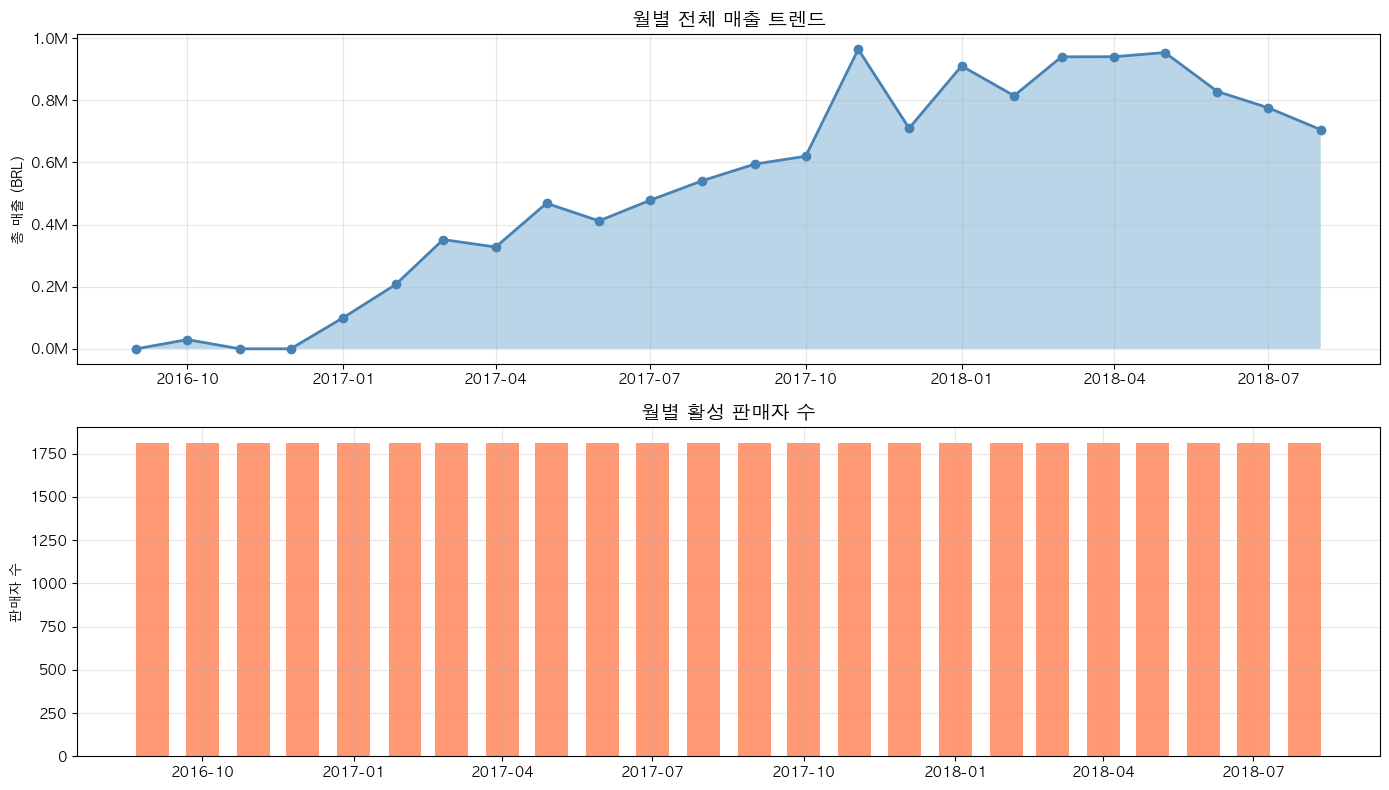

그래프 저장: eda_monthly_trend.png


In [49]:
# ─────────────────────────────────────────────
# Step 4-1. 월별 전체 매출 트렌드
# ─────────────────────────────────────────────
monthly_total = (
    monthly_valid
    .groupby('year_month_dt')
    .agg(total_revenue=('monthly_revenue', 'sum'),
         active_sellers=('seller_id', 'nunique'))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(monthly_total['year_month_dt'], monthly_total['total_revenue'], 
         marker='o', linewidth=2, color='steelblue')
ax1.fill_between(monthly_total['year_month_dt'], monthly_total['total_revenue'], alpha=0.3)
ax1.set_title('월별 전체 매출 트렌드', fontsize=14, fontweight='bold')
ax1.set_ylabel('총 매출 (BRL)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.bar(monthly_total['year_month_dt'], monthly_total['active_sellers'],
        color='coral', alpha=0.8, width=20)
ax2.set_title('월별 활성 판매자 수', fontsize=14, fontweight='bold')
ax2.set_ylabel('판매자 수')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PATH.parent / 'eda_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('그래프 저장: eda_monthly_trend.png')

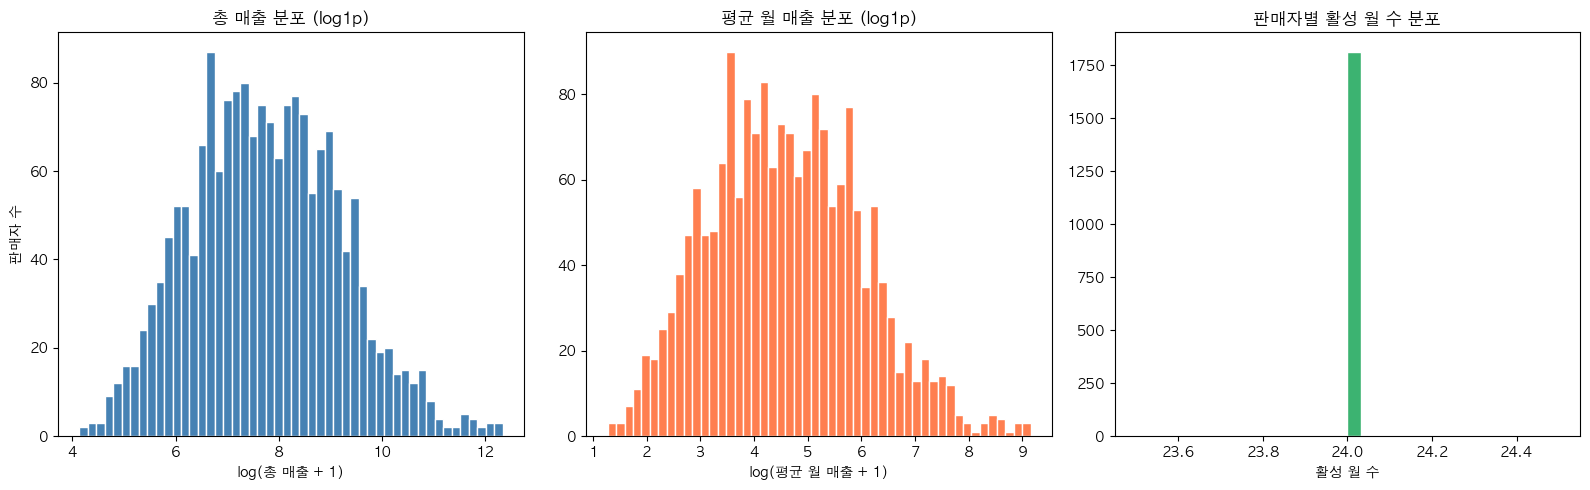

=== 판매자별 매출 통계 ===
           total_rev  avg_monthly_rev  std_monthly_rev  max_monthly_rev  \
count    1814.000000      1814.000000      1814.000000      1814.000000   
mean     6984.390044       291.016252       436.580830      1598.634928   
std     17334.319407       722.263309       867.553848      3142.958016   
min        61.470000         2.561250         7.217371        24.490000   
25%       802.950000        33.456250        82.917644       325.100000   
50%      2172.905000        90.537708       186.381363       708.995000   
75%      6408.817500       267.034063       445.884141      1641.325000   
max    226987.930000      9457.830417     16145.185995     62507.570000   

       n_months  
count    1814.0  
mean       24.0  
std         0.0  
min        24.0  
25%        24.0  
50%        24.0  
75%        24.0  
max        24.0  


In [50]:
# ─────────────────────────────────────────────
# Step 4-2. 판매자별 총 매출 분포
# ─────────────────────────────────────────────
seller_total_rev = (
    monthly_valid
    .groupby('seller_id')['monthly_revenue']
    .agg(['sum', 'mean', 'std', 'max', 'count'])
    .rename(columns={'sum': 'total_rev', 'mean': 'avg_monthly_rev',
                     'std': 'std_monthly_rev', 'max': 'max_monthly_rev',
                     'count': 'n_months'})
    .reset_index()
)
seller_total_rev['std_monthly_rev'] = seller_total_rev['std_monthly_rev'].fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 총 매출 분포 (로그 스케일)
axes[0].hist(np.log1p(seller_total_rev['total_rev']), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('총 매출 분포 (log1p)', fontsize=12)
axes[0].set_xlabel('log(총 매출 + 1)')
axes[0].set_ylabel('판매자 수')

# 평균 월 매출 분포
axes[1].hist(np.log1p(seller_total_rev['avg_monthly_rev']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('평균 월 매출 분포 (log1p)', fontsize=12)
axes[1].set_xlabel('log(평균 월 매출 + 1)')

# 활성 월 수 분포
axes[2].hist(seller_total_rev['n_months'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('판매자별 활성 월 수 분포', fontsize=12)
axes[2].set_xlabel('활성 월 수')

plt.tight_layout()
plt.savefig(DATA_PATH.parent / 'eda_seller_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== 판매자별 매출 통계 ===')
print(seller_total_rev[['total_rev', 'avg_monthly_rev', 'std_monthly_rev', 'max_monthly_rev', 'n_months']].describe())

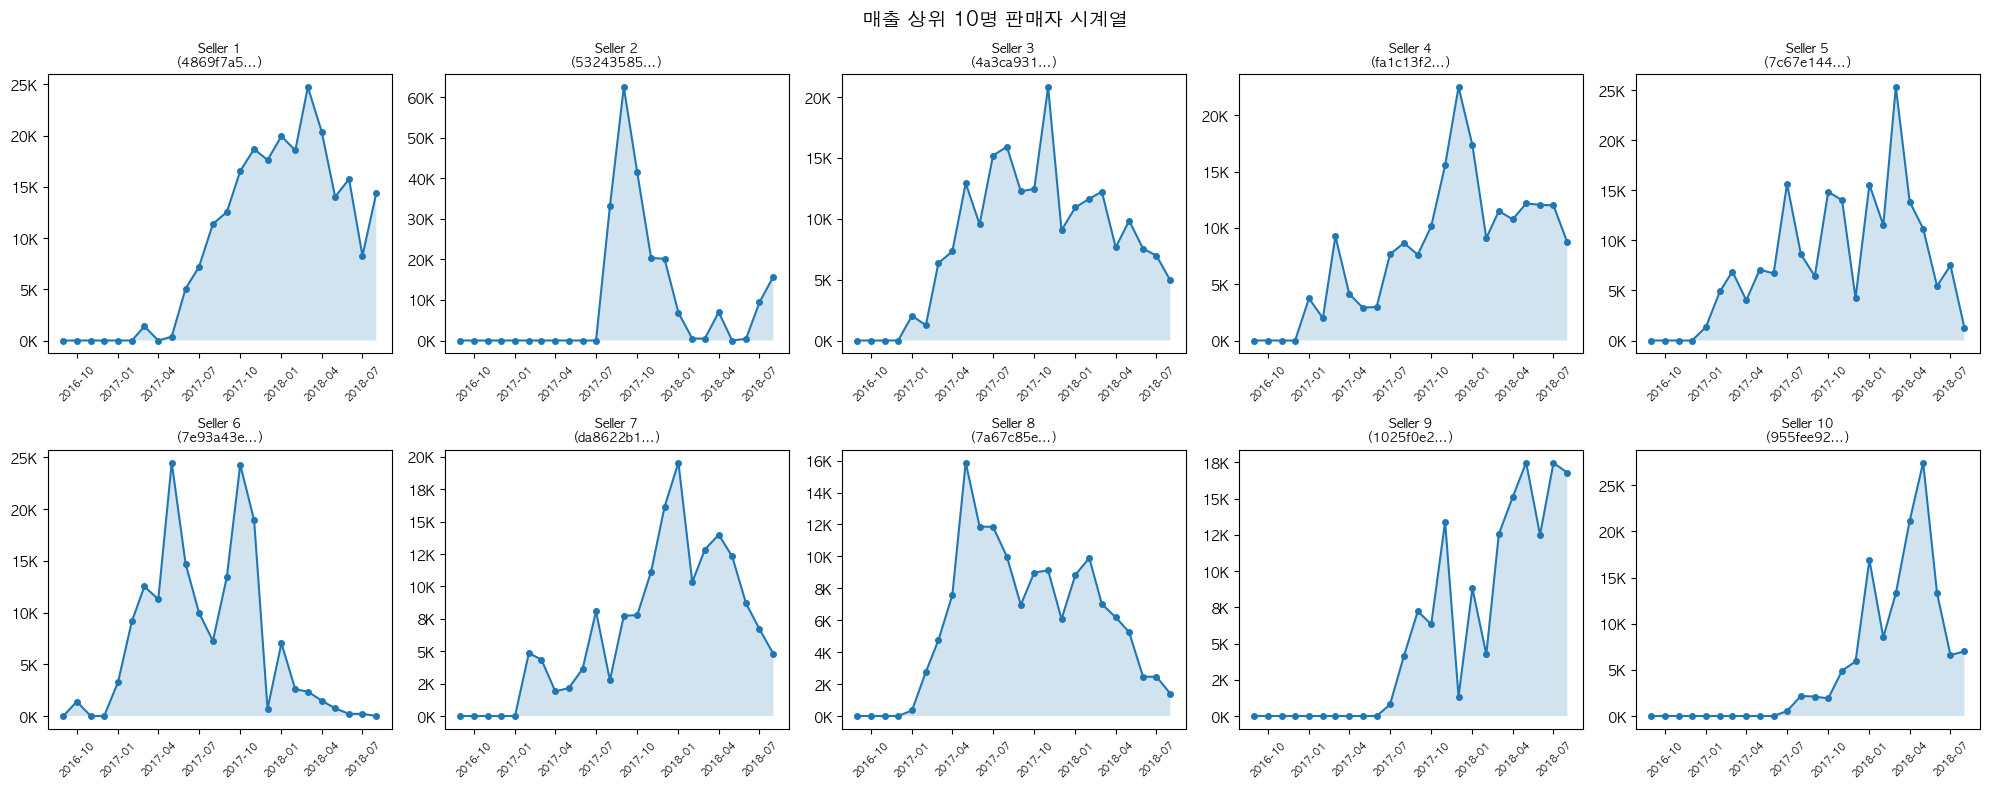


✅ Step 4 완료 - EDA 완료


In [51]:
# ─────────────────────────────────────────────
# Step 4-3. 상위 판매자 10명 시계열 시각화
# ─────────────────────────────────────────────
top10_sellers = seller_total_rev.nlargest(10, 'total_rev')['seller_id'].tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, sid in enumerate(top10_sellers):
    ts = monthly_valid[monthly_valid['seller_id'] == sid].sort_values('year_month_dt')
    axes[i].plot(ts['year_month_dt'], ts['monthly_revenue'],
                 marker='o', linewidth=1.5, markersize=4)
    axes[i].fill_between(ts['year_month_dt'], ts['monthly_revenue'], alpha=0.2)
    axes[i].set_title(f'Seller {i+1}\n({sid[:8]}...)', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K'))

plt.suptitle('매출 상위 10명 판매자 시계열', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH.parent / 'eda_top10_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Step 4 완료 - EDA 완료')

---
## Step 5. 판매자 유형 분류
- 변동계수(CV), 트렌드, 계절성 지표 계산
- K-Means 클러스터링으로 4개 유형 분류
- 유형별 대표 판매자 선정

In [53]:
# ─────────────────────────────────────────────
# Step 5-1. 판매자별 특성 피처 계산 (v2)
# 2. 개선된 피처 계산 (활성 구간 기준)
# ─────────────────────────────────────────────────────────────
def calc_seller_features_v2(df_seller):
    """
    활성 구간(첫 판매~마지막 판매 사이) 기준으로 피처 계산
    """
    results = []

    for seller_id, group in df_seller.groupby('seller_id'):
        grp = group.sort_values('year_month_dt')
        ts_full = grp['monthly_revenue'].values
        n_full = len(ts_full)

        # 활성 구간: 첫 판매 ~ 마지막 판매 사이
        nonzero_idx = np.where(ts_full > 0)[0]
        if len(nonzero_idx) < 3:
            continue

        first_active = nonzero_idx[0]
        last_active  = nonzero_idx[-1]
        ts_active = ts_full[first_active:last_active + 1]
        n_active = len(ts_active)

        # 활성 구간 통계
        mean_active = np.mean(ts_active)
        std_active  = np.std(ts_active)

        # 변동계수 (CV): 활성 구간 기준
        active_cv = std_active / (mean_active + 1e-8)

        # 활성 구간 선형 트렌드
        x = np.arange(n_active)
        if std_active > 0 and n_active >= 3:
            slope, _, r_val, _, _ = linregress(x, ts_active)
            active_trend_slope = slope / (mean_active + 1e-8)
            active_trend_r2    = r_val ** 2
        else:
            active_trend_slope = 0.0
            active_trend_r2    = 0.0

        # 활성 구간 내 영매출 비율
        active_zero_ratio = np.sum(ts_active == 0) / n_active

        # 전체 기간 영매출 비율 (입점 타이밍 파악)
        global_zero_ratio = np.sum(ts_full == 0) / n_full

        # 활성 월 비율 (전체 기간 대비 판매 발생 월)
        active_months_ratio = len(nonzero_idx) / n_full

        # 계절성 강도: 활성 구간 내 월별 평균의 변동
        months = grp.iloc[first_active:last_active + 1]['year_month_dt'].dt.month.values
        month_means = {}
        for m, v in zip(months, ts_active):
            month_means.setdefault(m, []).append(v)

        if len(month_means) >= 3:
            seas_vals = [np.mean(v) for v in month_means.values()]
            seasonality_strength = np.std(seas_vals) / (std_active + 1e-8)
        else:
            seasonality_strength = 0.0

        log_avg_active_rev = np.log1p(mean_active)
        spike_ratio        = np.max(ts_active) / (mean_active + 1e-8)

        results.append({
            'seller_id'           : seller_id,
            'active_cv'           : active_cv,
            'active_trend_slope'  : active_trend_slope,
            'active_trend_r2'     : active_trend_r2,
            'seasonality_strength': seasonality_strength,
            'active_zero_ratio'   : active_zero_ratio,
            'global_zero_ratio'   : global_zero_ratio,
            'log_avg_active_rev'  : log_avg_active_rev,
            'spike_ratio'         : spike_ratio,
            'active_months_ratio' : active_months_ratio,
            'n_active'            : n_active,
            'mean_active_rev'     : mean_active,
        })

    return pd.DataFrame(results)

print("피처 계산 중 (활성 구간 기준 v2)...")
sf = calc_seller_features_v2(monthly_valid)
print(f"피처 계산 완료: {sf.shape}")



피처 계산 중 (활성 구간 기준 v2)...
피처 계산 완료: (1814, 12)


In [60]:
# ─────────────────────────────────────────────
# Step 5-2. K-Means 클러스터링 기반 모델 (v2)
# 3. K-Means 클러스터링
# ─────────────────────────────────────────────────────────────
feature_cols = [
    'active_cv', 'active_trend_slope', 'active_trend_r2',
    'seasonality_strength', 'active_zero_ratio',
    'log_avg_active_rev', 'spike_ratio', 'active_months_ratio',
]

X = sf[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow + Silhouette
K_range = range(2, 8)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4')
axes[0].set_title('Elbow Method (v2 피처)', fontsize=12)
axes[0].set_xlabel('K (클러스터 수)'); axes[0].set_ylabel('Inertia')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, marker='s', color='coral', linewidth=2)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4')
axes[1].set_title('Silhouette Score (v2 피처)', fontsize=12)
axes[1].set_xlabel('K (클러스터 수)'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PATH / 'clustering_knee.png', dpi=150, bbox_inches='tight')
plt.close()
print("K별 Silhouette:", {k: round(s,4) for k,s in zip(K_range, silhouettes)})

# K=4 최종 클러스터링
N_CLUSTERS = 4
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
sf['cluster'] = km_final.fit_predict(X_scaled)

K별 Silhouette: {2: 0.2545, 3: 0.2285, 4: 0.2395, 5: 0.261, 6: 0.2462, 7: 0.2213}


In [61]:
# ─────────────────────────────────────────────
# Step 5-3. 클러스터 프로파일 (v2)
# 4. 클러스터 프로파일 출력
# ─────────────────────────────────────────────────────────────
cluster_profile = sf.groupby('cluster').agg(
    avg_cv             =('active_cv'           , 'mean'),
    avg_trend_slope    =('active_trend_slope'  , 'mean'),
    avg_trend_r2       =('active_trend_r2'     , 'mean'),
    avg_seasonality    =('seasonality_strength', 'mean'),
    avg_active_zero    =('active_zero_ratio'   , 'mean'),
    avg_active_ratio   =('active_months_ratio' , 'mean'),
    avg_log_rev        =('log_avg_active_rev'  , 'mean'),
    count              =('seller_id'           , 'count')
).round(4)

print("\n=== 클러스터 프로파일 ===")
print(cluster_profile.to_string())



=== 클러스터 프로파일 ===
         avg_cv  avg_trend_slope  avg_trend_r2  avg_seasonality  avg_active_zero  avg_active_ratio  avg_log_rev  count
cluster                                                                                                               
0        1.5046          -0.0167        0.1261           0.9417           0.4916            0.2386       4.5490    373
1        0.7724          -0.0066        0.1103           1.0000           0.1200            0.3207       5.8116    885
2        0.8226           0.0062        0.1560           0.7237           0.1116            0.6881       6.4104    251
3        0.6107           0.0371        0.6365           0.9999           0.0481            0.1859       5.6715    305


In [57]:
# ─────────────────────────────────────────────
# Step 5-4. 유형 레이블 할당 (v2: 안정형 우선 복합 점수 방식)
# 5. 개선된 레이블링 규칙
# ─────────────────────────────────────────────────────────────
label_map = {}
remaining = set(range(N_CLUSTERS))

# 1) 안정형: CV 낮음 + 활성 비율 높음 (오래 꾸준히 판매)
stable_score = -cluster_profile['avg_cv'] + cluster_profile['avg_active_ratio']
stable_c = stable_score.idxmax()
label_map[stable_c] = '안정형 (Stable)'
remaining.discard(stable_c)

# 2) 성장형: trend_slope*trend_r2 복합 점수 (실질적 선형 우상향)
growth_score = (
    cluster_profile.loc[list(remaining), 'avg_trend_slope'].clip(0) *
    cluster_profile.loc[list(remaining), 'avg_trend_r2']
)
growth_c = growth_score.idxmax()
label_map[growth_c] = '성장형 (Growth)'
remaining.discard(growth_c)

# 3) 불안정형: 활성 구간 내에도 영매출이 많은 클러스터
volatile_c = cluster_profile.loc[list(remaining), 'avg_active_zero'].idxmax()
label_map[volatile_c] = '불안정형 (Volatile)'
remaining.discard(volatile_c)

# 4) 나머지 = 계절형
seasonal_c = list(remaining)[0]
label_map[seasonal_c] = '계절형 (Seasonal)'

print("\n=== 클러스터 → 유형 매핑 (v2) ===")
for c, label in sorted(label_map.items()):
    print(f"  클러스터 {c} → {label}")

sf['seller_type'] = sf['cluster'].map(label_map)
print("\n=== 유형별 판매자 수 ===")
print(sf['seller_type'].value_counts())




=== 클러스터 → 유형 매핑 (v2) ===
  클러스터 0 → 불안정형 (Volatile)
  클러스터 1 → 계절형 (Seasonal)
  클러스터 2 → 안정형 (Stable)
  클러스터 3 → 성장형 (Growth)

=== 유형별 판매자 수 ===
계절형 (Seasonal)     885
불안정형 (Volatile)    373
성장형 (Growth)       305
안정형 (Stable)       251
Name: seller_type, dtype: int64



=== 유형별 핵심 피처 평균 ===
                 active_cv  active_trend_slope  active_trend_r2  active_zero_ratio  active_months_ratio  log_avg_active_rev  mean_active_rev
seller_type                                                                                                                                 
계절형 (Seasonal)      0.7724             -0.0066           0.1103             0.1200               0.3207              5.8116         675.9750
불안정형 (Volatile)     1.5046             -0.0167           0.1261             0.4916               0.2386              4.5490         162.6034
성장형 (Growth)        0.6107              0.0371           0.6365             0.0481               0.1859              5.6715         549.5098
안정형 (Stable)        0.8226              0.0062           0.1560             0.1116               0.6881              6.4104        1179.9043


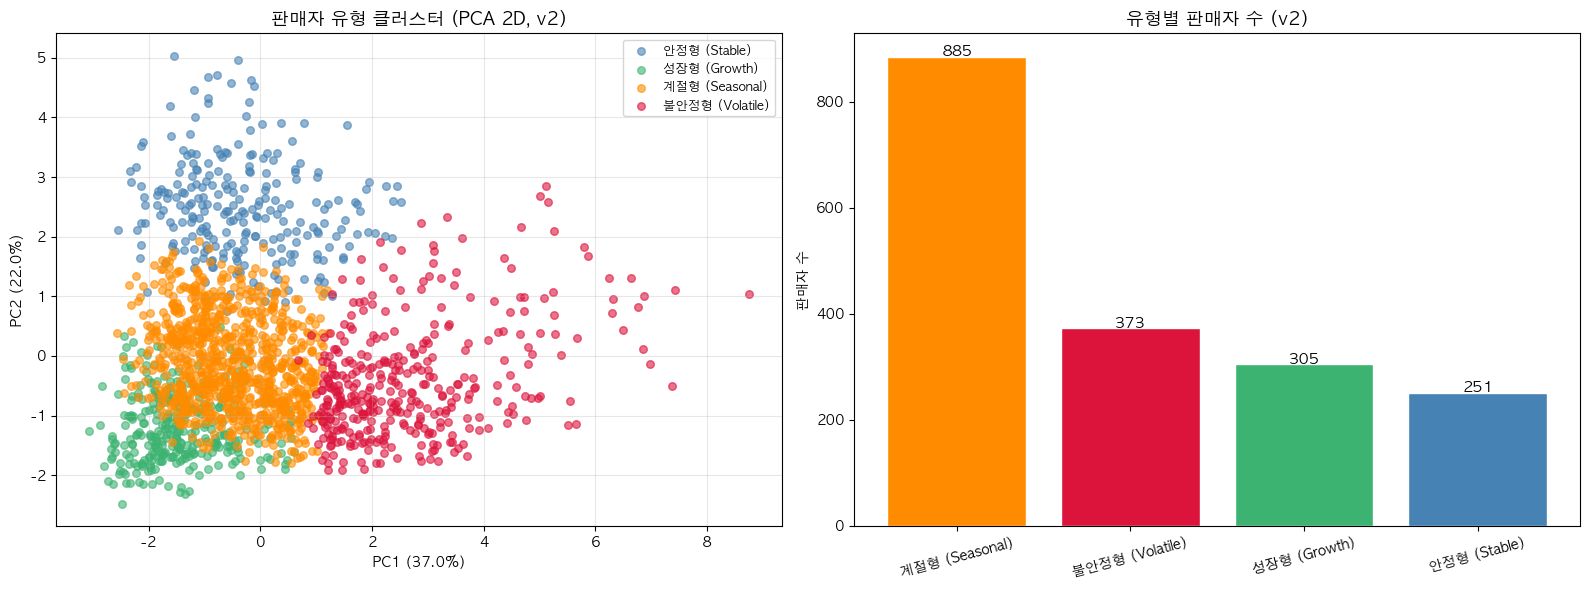

In [63]:
# ─────────────────────────────────────────────
# Step 5-5. 유형별 시각화 (v2)
# 6. 유형별 피처 프로파일 출력
# ─────────────────────────────────────────────────────────────
print("\n=== 유형별 핵심 피처 평균 ===")
key_cols = ['active_cv', 'active_trend_slope', 'active_trend_r2',
            'active_zero_ratio', 'active_months_ratio',
            'log_avg_active_rev', 'mean_active_rev']
print(sf.groupby('seller_type')[key_cols].mean().round(4).to_string())

# ─────────────────────────────────────────────────────────────
# 7. 유형별 시각화 (PCA + 판매자 수)
# ─────────────────────────────────────────────────────────────
color_map = {
    '안정형 (Stable)': 'steelblue',
    '성장형 (Growth)': 'mediumseagreen',
    '계절형 (Seasonal)': 'darkorange',
    '불안정형 (Volatile)': 'crimson',
}

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
sf['pca1'] = X_pca[:, 0]
sf['pca2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for stype, color in color_map.items():
    mask = sf['seller_type'] == stype
    axes[0].scatter(sf.loc[mask, 'pca1'], sf.loc[mask, 'pca2'],
                    c=color, label=stype, alpha=0.6, s=30)
axes[0].set_title('판매자 유형 클러스터 (PCA 2D, v2)', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

type_counts = sf['seller_type'].value_counts()
colors_bar = [color_map.get(t, 'gray') for t in type_counts.index]
bars = axes[1].bar(type_counts.index, type_counts.values, color=colors_bar, edgecolor='white')
axes[1].set_title('유형별 판매자 수 (v2)', fontsize=13)
axes[1].set_ylabel('판매자 수')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(DATA_PATH / 'clustering_result.png', dpi=150, bbox_inches='tight')
# plt.close()




=== 유형별 대표 판매자 ===
                             seller_id      seller_type  active_cv  active_trend_slope  active_trend_r2  active_zero_ratio  mean_active_rev
1176  a369d693961cb93b61ca2cc518872a85   계절형 (Seasonal)   0.779264           -0.058914         0.038105           0.111111       288.555556
1477  cf2384dd2f1dddea3f838efed0945e65  불안정형 (Volatile)   1.393557           -0.113859         0.179681           0.555556       116.750000
1483  cfe94489ddd337d1e29e12f2a7205d10     성장형 (Growth)   0.489473            0.177083         0.523551           0.000000       339.428571
572   4e17c65a516f69d023a2ae78b84f28d6     안정형 (Stable)   0.850387            0.048384         0.087135           0.111111       424.403333

✅ 시각화 저장 완료: representative_sellers.png


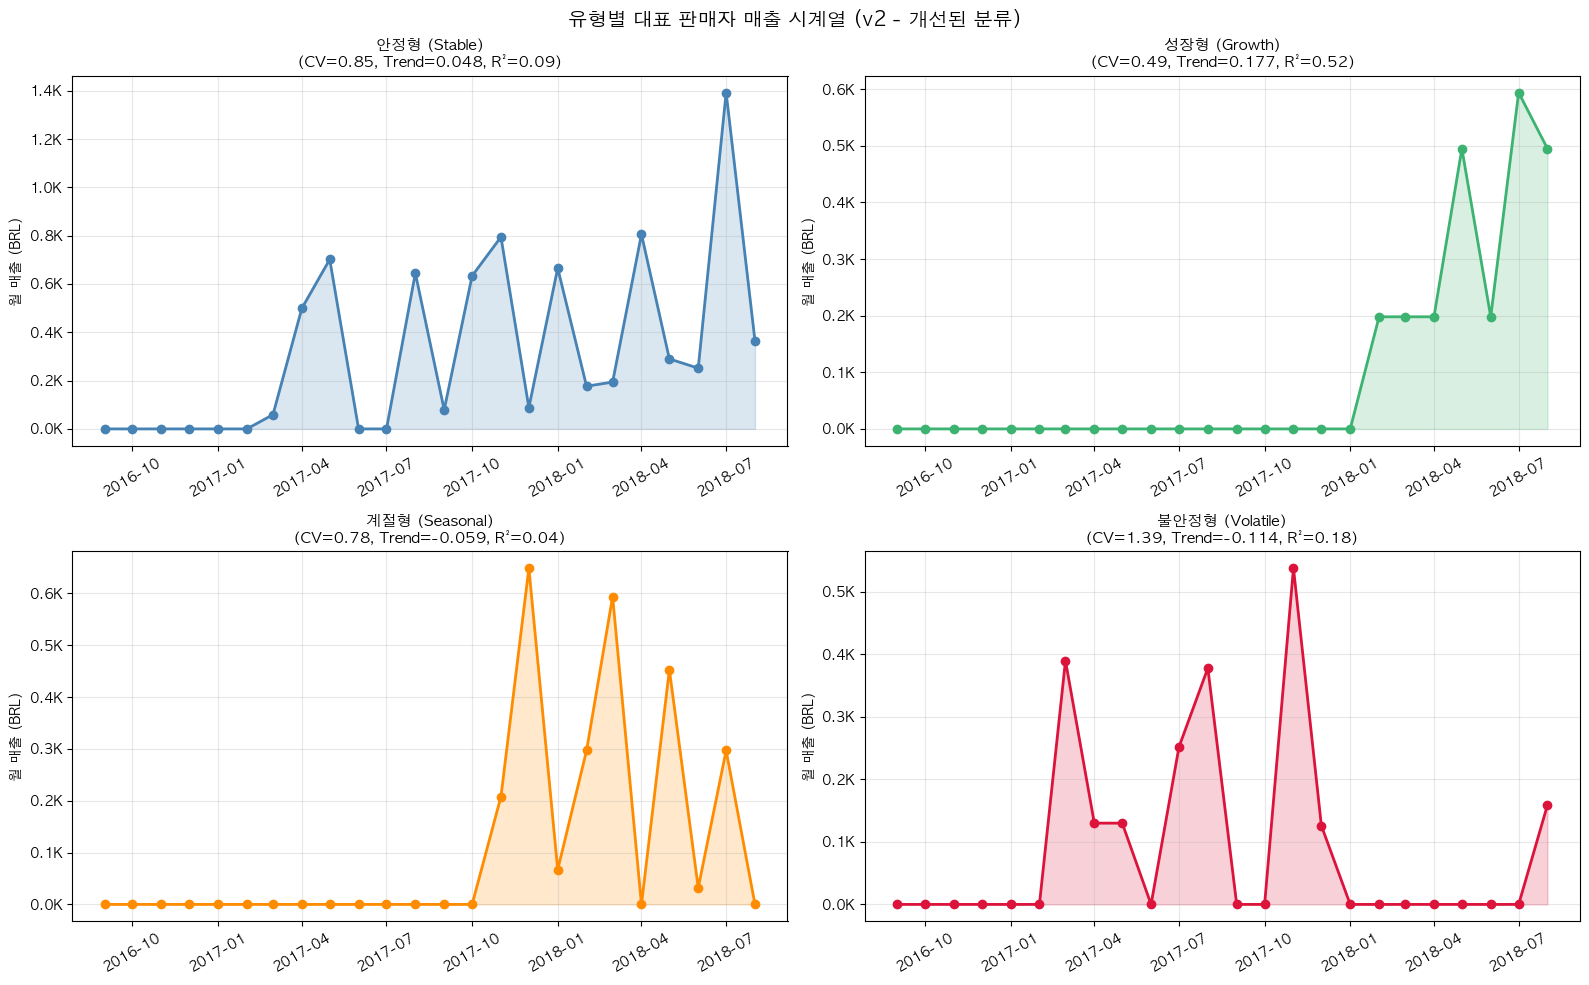

In [65]:
# ─────────────────────────────────────────────
# Step 5-6. 유형별 대표 판매자 선정 및 시계열 예시 비교
# 8. 유형별 대표 판매자 선정 및 시계열 시각화
# ─────────────────────────────────────────────────────────────
distances = pairwise_distances(X_scaled, km_final.cluster_centers_)
sf['dist_to_center'] = [distances[i, c] for i, c in enumerate(sf['cluster'])]

rep_sellers = (
    sf.groupby('seller_type', group_keys=False)
    .apply(lambda g: g.nsmallest(1, 'dist_to_center'))
    [['seller_id', 'seller_type', 'active_cv', 'active_trend_slope',
      'active_trend_r2', 'active_zero_ratio', 'mean_active_rev']]
)
print("\n=== 유형별 대표 판매자 ===")
print(rep_sellers.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
type_order = ['안정형 (Stable)', '성장형 (Growth)', '계절형 (Seasonal)', '불안정형 (Volatile)']

for i, stype in enumerate(type_order):
    row = rep_sellers[rep_sellers['seller_type'] == stype]
    if len(row) == 0:
        continue
    row = row.iloc[0]
    sid = row['seller_id']
    ts = monthly_valid[monthly_valid['seller_id'] == sid].sort_values('year_month_dt')
    color = color_map.get(stype, 'gray')

    axes[i].plot(ts['year_month_dt'], ts['monthly_revenue'],
                 marker='o', linewidth=2, color=color)
    axes[i].fill_between(ts['year_month_dt'], ts['monthly_revenue'], alpha=0.2, color=color)
    axes[i].set_title(
        f'{stype}\n(CV={row["active_cv"]:.2f}, Trend={row["active_trend_slope"]:.3f}, R²={row["active_trend_r2"]:.2f})',
        fontsize=11, fontweight='bold'
    )
    axes[i].set_ylabel('월 매출 (BRL)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(True, alpha=0.3)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e3:.1f}K'))

plt.suptitle('유형별 대표 판매자 매출 시계열 (v2 - 개선된 분류)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH / 'representative_sellers.png', dpi=150, bbox_inches='tight')
# plt.close()
print("\n✅ 시각화 저장 완료: representative_sellers.png")

In [67]:
# ─────────────────────────────────────────────
# 결과 저장
# 9. 결과 저장
# ─────────────────────────────────────────────────────────────
sf.to_csv(DATA_PATH / 'seller_features_with_type.csv', index=False)
print("✅ seller_features_with_type.csv 저장 완료")

monthly_final = monthly_valid.merge(
    sf[['seller_id', 'cluster', 'seller_type']], on='seller_id', how='left'
)
monthly_final.to_csv(DATA_PATH / 'monthly_seller_with_type.csv', index=False)
print("✅ monthly_seller_with_type.csv 저장 완료")

print("\n=== 전체 완료 ===")
print(sf['seller_type'].value_counts())


✅ seller_features_with_type.csv 저장 완료
✅ monthly_seller_with_type.csv 저장 완료

=== 전체 완료 ===
계절형 (Seasonal)     885
불안정형 (Volatile)    373
성장형 (Growth)       305
안정형 (Stable)       251
Name: seller_type, dtype: int64


---
## 다음 단계 (Phase 3 예고)

### Phase 3-A: CVaR 최적화
- 유형별 시계열 → `TFT / N-BEATS` 등으로 예측 구간 산출
- 예측 불확실성 → CVaR 정량화 → 최적 `L*`, `r*` 결정

### Phase 3-B: 강화학습 동적 조정
- 대출 집행 후 매달 PPO/SAC 에이전트가 수수료율 재조정
- 환경: 판매자 유형별 커스텀 Gym 환경 구성